## Step 1: Data Loading and Initial Inspection

In this step, we load the rainfall dataset and perform an initial inspection.

Objectives:
- Verify that the data is loaded correctly
- Understand the structure of the dataset
- Identify useful and unnecessary columns
- Check for inconsistencies or missing values

This step is important to ensure that further analysis is based on clean and reliable data.

In [11]:
import pandas as pd

# Load the dataset
df = pd.read_excel("BookI30.xlsx")   # make sure file is uploaded in Colab

# Display first few rows
df.head()

,s.no,time_since_beginning,cumulative_rainfall_mm,duration_min,amount_mm,intensity_mm_hr
0,1,9:00-9:15 pm,0.50,15,0.50,2.0
1,2,9:15-11:00 pm,0.50,105,0.00,0.0
2,3,11:00-11:15 pm,1.25,15,0.75,3.0
3,4,11:15-11:45 pm,1.75,30,0.50,1.0
4,5,11:45-12:25 pm,1.75,40,0.00,0.0


### Inspecting Data Structure

We check:
- Column names
- Data types
- Missing values

In [12]:
# Check structure
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   s.no                    17 non-null     int64  
 1   time_since_beginning    17 non-null     object 
 2   cumulative_rainfall_mm  17 non-null     float64
 3   duration_min            17 non-null     int64  
 4   amount_mm               17 non-null     float64
 5   intensity_mm_hr         17 non-null     float64
dtypes: float64(3), int64(2), object(1)
memory usage: 948.0+ bytes


,0
s.no,0
time_since_beginning,0
cumulative_rainfall_mm,0
duration_min,0
amount_mm,0
intensity_mm_hr,0


### Understanding Columns

We examine each column to decide:
- Which columns are needed for analysis
- Which columns can be removed

For this project, we mainly need:
- Storm duration (minutes)
- Rainfall amount (mm)

In [13]:
# Print column names
print(df.columns)

Index(['s.no', 'time_since_beginning', 'cumulative_rainfall_mm',
       'duration_min', 'amount_mm', 'intensity_mm_hr'],
      dtype='object')


### Data Cleaning

We retain only relevant columns required for rainfall analysis.

Unnecessary columns such as:
- Serial number
- Time strings
- Precomputed intensity

are removed to simplify processing.

In [14]:
df = df[['duration_min', 'amount_mm']]

# Rename for simplicity
df.columns = ['duration', 'rainfall']

df.head()

,duration,rainfall
0,15,0.50
1,105,0.00
2,15,0.75
3,30,0.50
4,40,0.00


## Step 2: Construct Minute-Level Rainfall Series

The rainfall data is given in intervals with total rainfall over each duration.

To analyze rainfall intensity properly, we convert this into a continuous time series.

Assumption:
- Rainfall is uniformly distributed within each interval.

Process:
- For each interval, rainfall is divided equally across each minute
- A minute-level rainfall series is constructed
- This allows application of a sliding window for I30 calculation

In [15]:
minute_rainfall = []

for i in range(len(df)):
    duration = int(df.loc[i, 'duration'])
    rainfall = df.loc[i, 'rainfall']

    if duration == 0:
        continue

    rain_per_min = rainfall / duration

    # repeat value for each minute
    minute_rainfall.extend([rain_per_min] * duration)

# Convert to pandas Series
minute_series = pd.Series(minute_rainfall)

print("Total minutes:", len(minute_series))
minute_series.head(20)

Total minutes: 660


,0
0,0.033333
1,0.033333
2,0.033333
3,0.033333
4,0.033333
5,0.033333
6,0.033333
7,0.033333
8,0.033333
9,0.033333


### Visualizing Minute-Level Rainfall

We plot the reconstructed rainfall series to verify distribution.

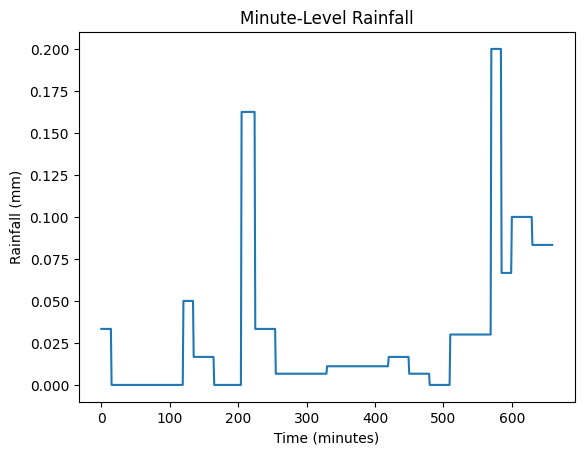

In [16]:
import matplotlib.pyplot as plt

plt.plot(minute_series)
plt.title("Minute-Level Rainfall")
plt.xlabel("Time (minutes)")
plt.ylabel("Rainfall (mm)")
plt.show()

## Step 3: Calculation of Maximum 30-Minute Rainfall Intensity (I30)

To determine rainfall erosivity, we compute the maximum rainfall intensity over any 30-minute period.

Method:
- A sliding window of 30 minutes is applied over the minute-level rainfall data
- Total rainfall within each 30-minute window is calculated
- This is converted to intensity (mm/hr)
- The maximum value obtained is defined as I30

This represents the peak erosive power of the rainfall event.

In [17]:
window_size = 30  # 30 minutes

intensities = []

for i in range(len(minute_series) - window_size):
    window_sum = minute_series[i:i+window_size].sum()

    # convert to mm/hr
    intensity = window_sum * 2

    intensities.append(intensity)

# Convert to series
intensity_series = pd.Series(intensities)

# Get I30
I30 = intensity_series.max()

print("I30 (mm/hr):", I30)
round(I30, 2)


I30 (mm/hr): 8.000000000000002


8.0

### Rainfall Intensity (30-min Sliding Window)

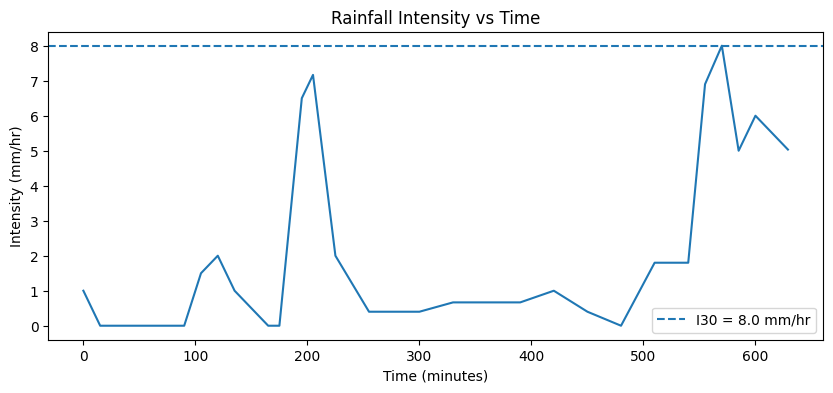

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(intensity_series)
plt.axhline(I30, linestyle='--', label=f'I30 = {round(I30,2)} mm/hr')
plt.title("Rainfall Intensity vs Time")
plt.xlabel("Time (minutes)")
plt.ylabel("Intensity (mm/hr)")
plt.legend()
plt.show()


### Kinetic Energy Distribution over Time

This graph shows how rainfall energy varies with time and highlights periods of high erosive potential.

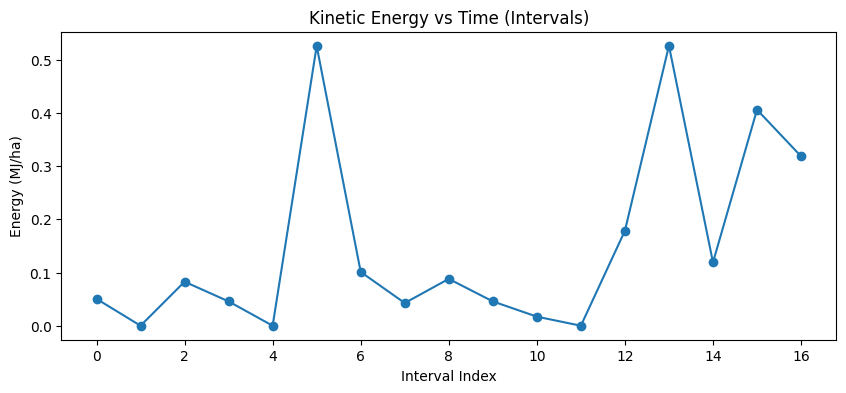

In [22]:
energy_list = []

for i in range(len(df)):
    rainfall = df.loc[i, 'rainfall']
    duration = df.loc[i, 'duration']

    if duration == 0:
        continue

    intensity = (rainfall / duration) * 60

    E = 0.29 * (1 - 0.72 * np.exp(-0.05 * intensity))

    energy_list.append(E * rainfall)

# Plot
plt.figure(figsize=(10,4))
plt.plot(energy_list, marker='o')
plt.title("Kinetic Energy vs Time (Intervals)")
plt.xlabel("Interval Index")
plt.ylabel("Energy (MJ/ha)")
plt.show()

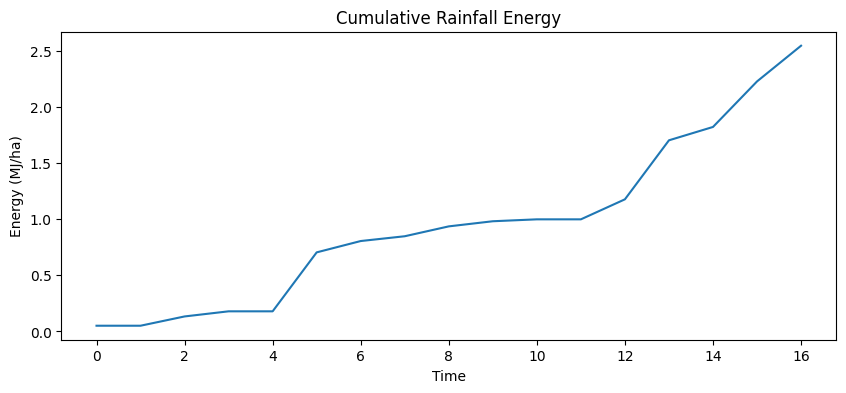

In [23]:
cumulative_energy = np.cumsum(energy_list)

plt.figure(figsize=(10,4))
plt.plot(cumulative_energy)
plt.title("Cumulative Rainfall Energy")
plt.xlabel("Time")
plt.ylabel("Energy (MJ/ha)")
plt.show()

## Step 4: Calculation of Rainfall Kinetic Energy

Rainfall kinetic energy represents the impact force of raindrops and plays a key role in soil erosion.

It is calculated using rainfall intensity.

Formula used:
E = 0.29 × (1 − 0.72 × e^(−0.05 × I))

Where:
- E = kinetic energy (MJ/ha/mm)
- I = rainfall intensity (mm/hr)

In [19]:
import numpy as np

total_energy = 0

for i in range(len(df)):
    rainfall = df.loc[i, 'rainfall']      # mm
    duration = df.loc[i, 'duration']      # min

    if duration == 0:
        continue

    # intensity (mm/hr)
    intensity = (rainfall / duration) * 60

    # kinetic energy (MJ/ha/mm)
    E = 0.29 * (1 - 0.72 * np.exp(-0.05 * intensity))

    # total energy contribution (MJ/ha)
    total_energy += E * rainfall

# print with units
print(f"Total Kinetic Energy: {round(total_energy, 3)} MJ/ha")

Total Kinetic Energy: 2.547 MJ/ha


## Step 5: Calculation of Rainfall Erosivity Index (EI30)

Rainfall erosivity is a measure of the potential of rainfall to cause soil erosion.

It is calculated as:

EI30 = Total Kinetic Energy × Maximum 30-minute Intensity (I30)

Where:
- EI30 represents the erosive power of rainfall
- Higher values indicate greater potential for soil loss

In [20]:
# EI30 calculation
EI30 = total_energy * I30

print(f"EI30 (Rainfall Erosivity Index): {round(EI30, 3)} MJ·mm/(ha·hr)")

EI30 (Rainfall Erosivity Index): 20.379 MJ·mm/(ha·hr)


## Step 6: Estimation of Soil Loss using USLE

The Universal Soil Loss Equation (USLE) is used to estimate soil erosion.

Formula:
A = R × K × LS × C × P

Where:
- A = Soil loss (tons/ha)
- R = Rainfall erosivity (EI30)
- K = Soil erodibility factor
- LS = Slope factor
- C = Crop management factor
- P = Conservation practice factor

In [21]:
# Assumed values (representative)
K = 0.28   # soil erodibility
LS = 1.5   # slope factor
C = 0.35   # crop factor
P = 0.5    # conservation factor

# Soil loss
A = EI30 * K * LS * C * P

print(f"Estimated Soil Loss: {round(A, 3)} tons/ha")

Estimated Soil Loss: 1.498 tons/ha


## Conclusion

In this study, rainfall data from a storm event was analyzed to estimate its erosive potential and resulting soil loss.

The rainfall data was first converted into a continuous minute-level time series using a uniform distribution assumption. A sliding 30-minute window approach was then applied to compute the maximum rainfall intensity (I30), which represents the peak erosive capacity of the storm.

Using intensity-based empirical relationships, the total kinetic energy of the rainfall was calculated. This was combined with I30 to obtain the rainfall erosivity index (EI30), a key parameter in soil erosion modeling.

Finally, the Universal Soil Loss Equation (USLE) was applied using representative values for soil, slope, crop cover, and conservation practices to estimate soil loss for the event.

The results demonstrate that short-duration, high-intensity rainfall significantly contributes to erosion potential. The methodology highlights how rainfall intensity, rather than total rainfall alone, plays a critical role in soil loss.

This analysis provides a simplified yet effective framework for understanding rainfall-driven soil erosion, which can be extended to annual estimation with long-term data.